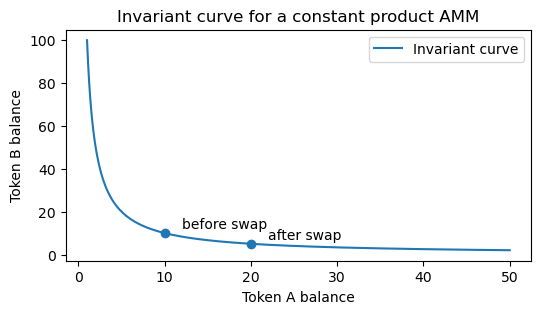

In [34]:
import numpy as np
import matplotlib.pyplot as plt

k = 100

x = np.linspace(1, 50, 400)
y = k / x

plt.figure(figsize=(6,3))

plt.plot(x, y, label="Invariant curve")

# punti swap
x1 = 10
y1 = k/x1

x2 = 20
y2 = k/x2

plt.scatter([x1, x2], [y1, y2])
plt.annotate("before swap", (x1, y1), xytext=(x1+2, y1+2))

plt.annotate("after swap", (x2, y2), xytext=(x2+2, y2+2))

plt.xlabel("Token A balance")
plt.ylabel("Token B balance")

plt.title("Invariant curve for a constant product AMM")

plt.legend()

plt.savefig("invariant_curve.pdf")
plt.show()

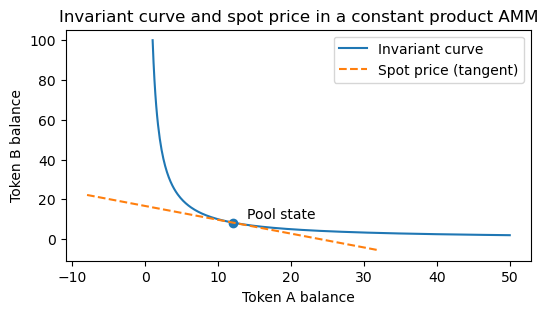

In [36]:
import numpy as np
import matplotlib.pyplot as plt

k = 100

# curva dell'invariante
x = np.linspace(1, 50, 400)
y = k / x

# punto stato pool
x0 = 12
y0 = k / x0

# derivata (slope della tangente)
slope = -k / (x0**2)

# retta tangente
tangent_x = np.linspace(x0-20, x0+20, 100)
tangent_y = y0 + slope*(tangent_x - x0)

plt.figure(figsize=(6,3))

plt.plot(x, y, label="Invariant curve")
plt.plot(tangent_x, tangent_y, "--", label="Spot price (tangent)")

plt.scatter(x0, y0)
plt.annotate("Pool state", (x0, y0), xytext=(x0+2, y0+2))

plt.xlabel("Token A balance")
plt.ylabel("Token B balance")

plt.title("Invariant curve and spot price in a constant product AMM")

plt.legend()

plt.savefig("amm_invariant_spotprice.png")
plt.show()

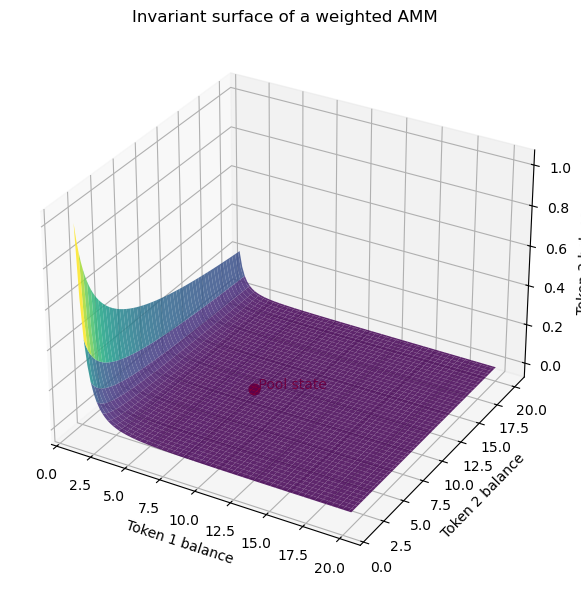

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# weights
W1 = 0.5
W2 = 0.1
W3 = 0.2

V = 100

# grid
b1 = np.linspace(1,20,100)
b2 = np.linspace(1,20,100)

B1, B2 = np.meshgrid(b1,b2)

B3 = (V/(B1**W1 * B2**W2))**(1/W3)

fig = plt.figure(figsize=(7,6))
ax = fig.add_subplot(111, projection='3d')

# smooth surface
surf = ax.plot_surface(
    B1, B2, B3,
    cmap='viridis',
    edgecolor='none',
    alpha=0.85
)

# example pool state
x0 = 8
y0 = 10
z0 = (V/(x0**W1 * y0**W2))**(1/W3)

ax.scatter(x0,y0,z0,color='red',s=60)
ax.text(x0,y0,z0," Pool state",color='red')

# labels
ax.set_xlabel("Token 1 balance")
ax.set_ylabel("Token 2 balance")
ax.set_zlabel("Token 3 balance")

ax.set_title("Invariant surface of a weighted AMM")

plt.tight_layout()

plt.savefig("amm_weighted_surface_clean.pdf")
plt.show()

Fig 1 saved.
Fig 2 saved.
Fig 3 saved.
Fig 4 saved.

All figures saved to /
PDF versions ready for LaTeX inclusion.


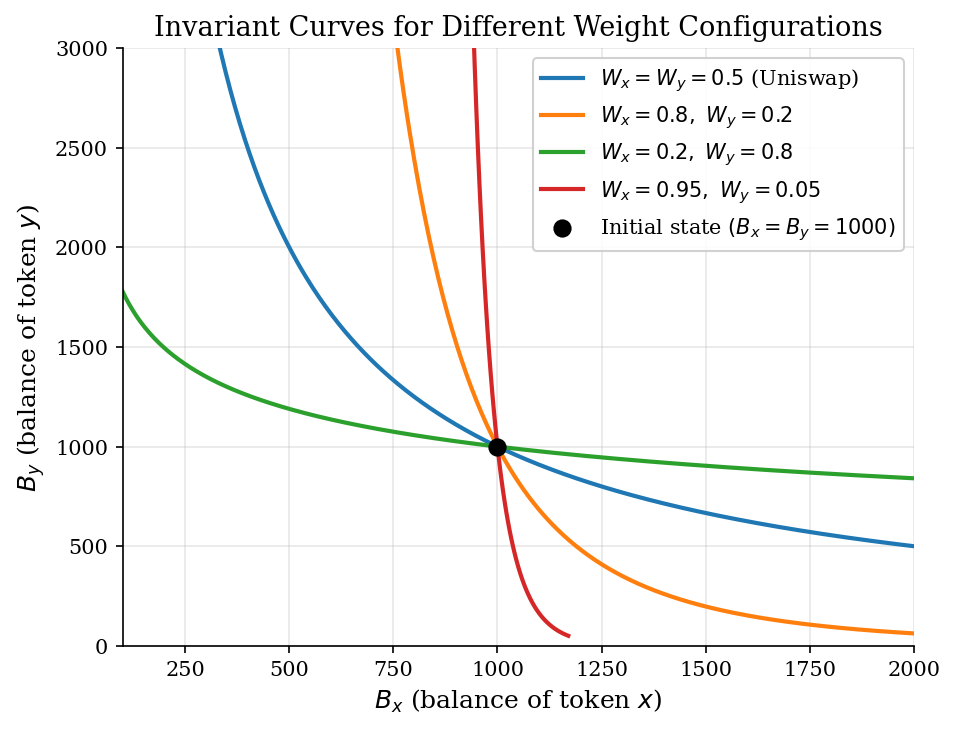

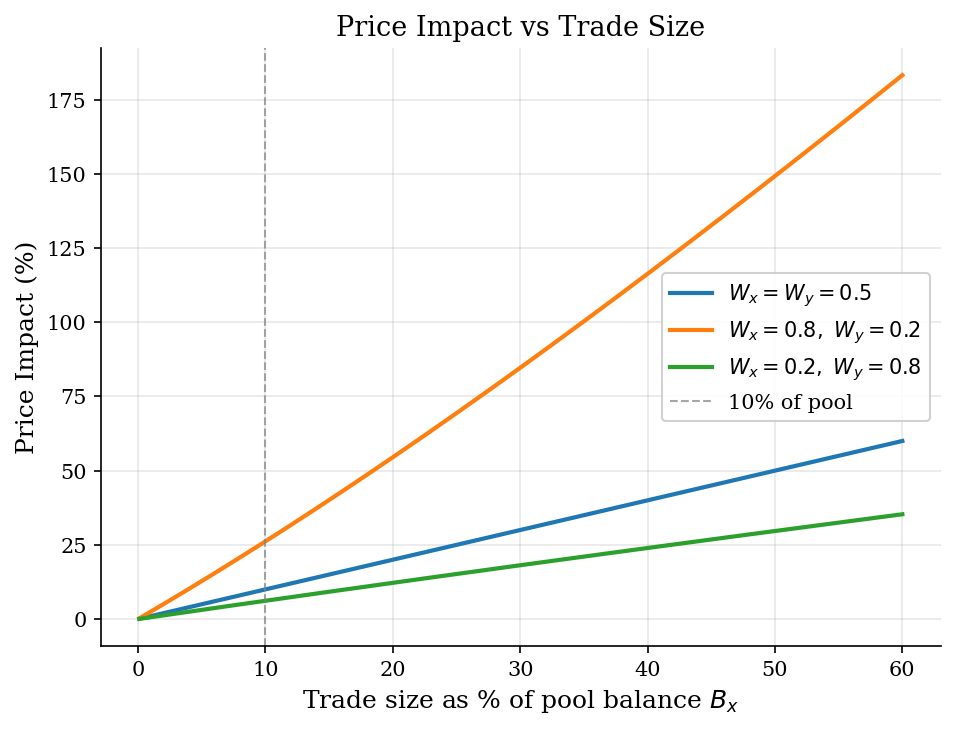

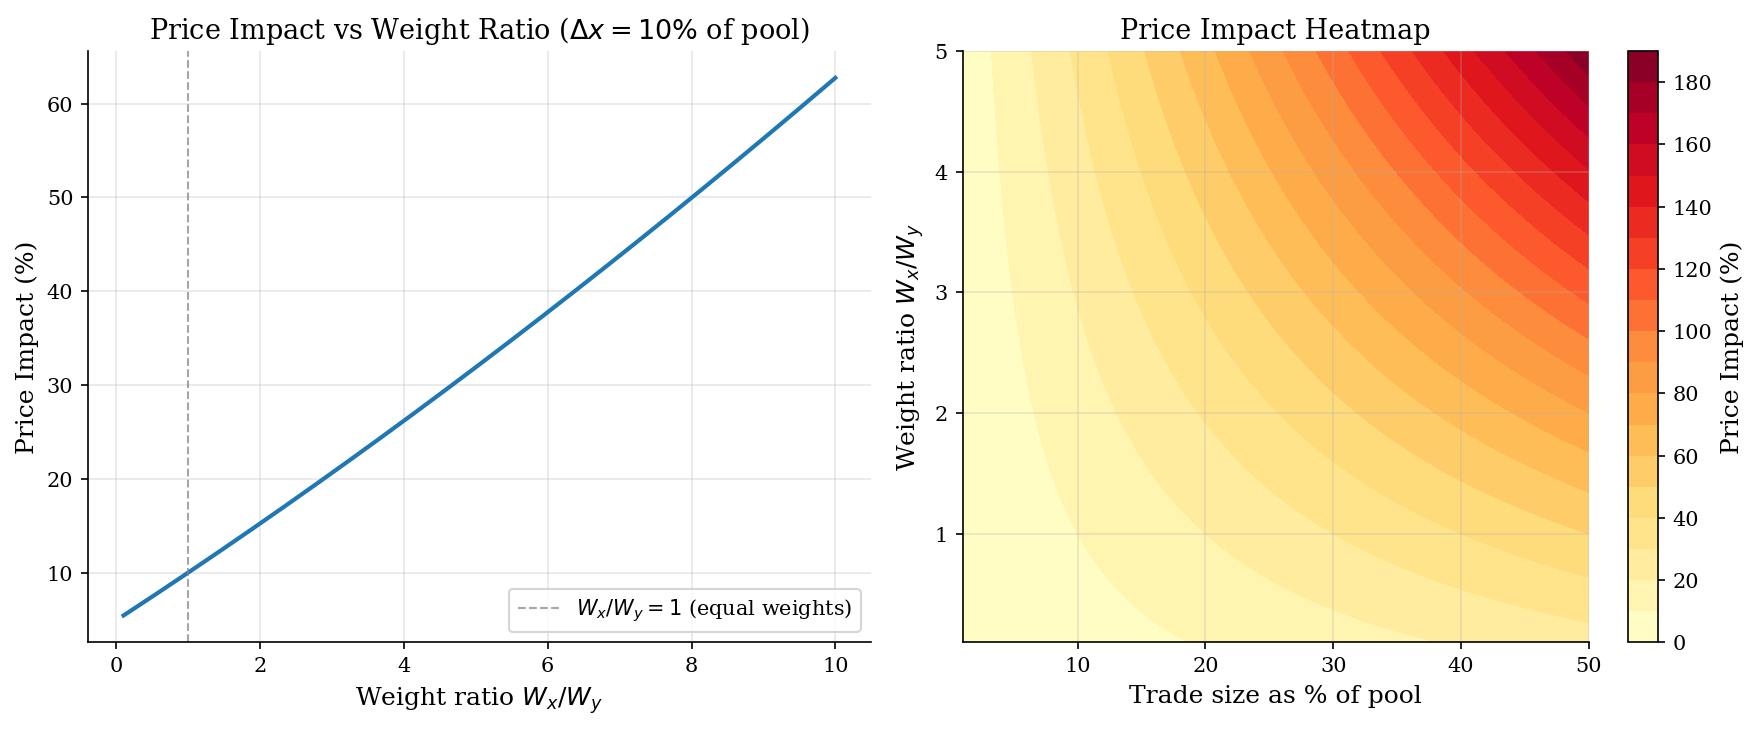

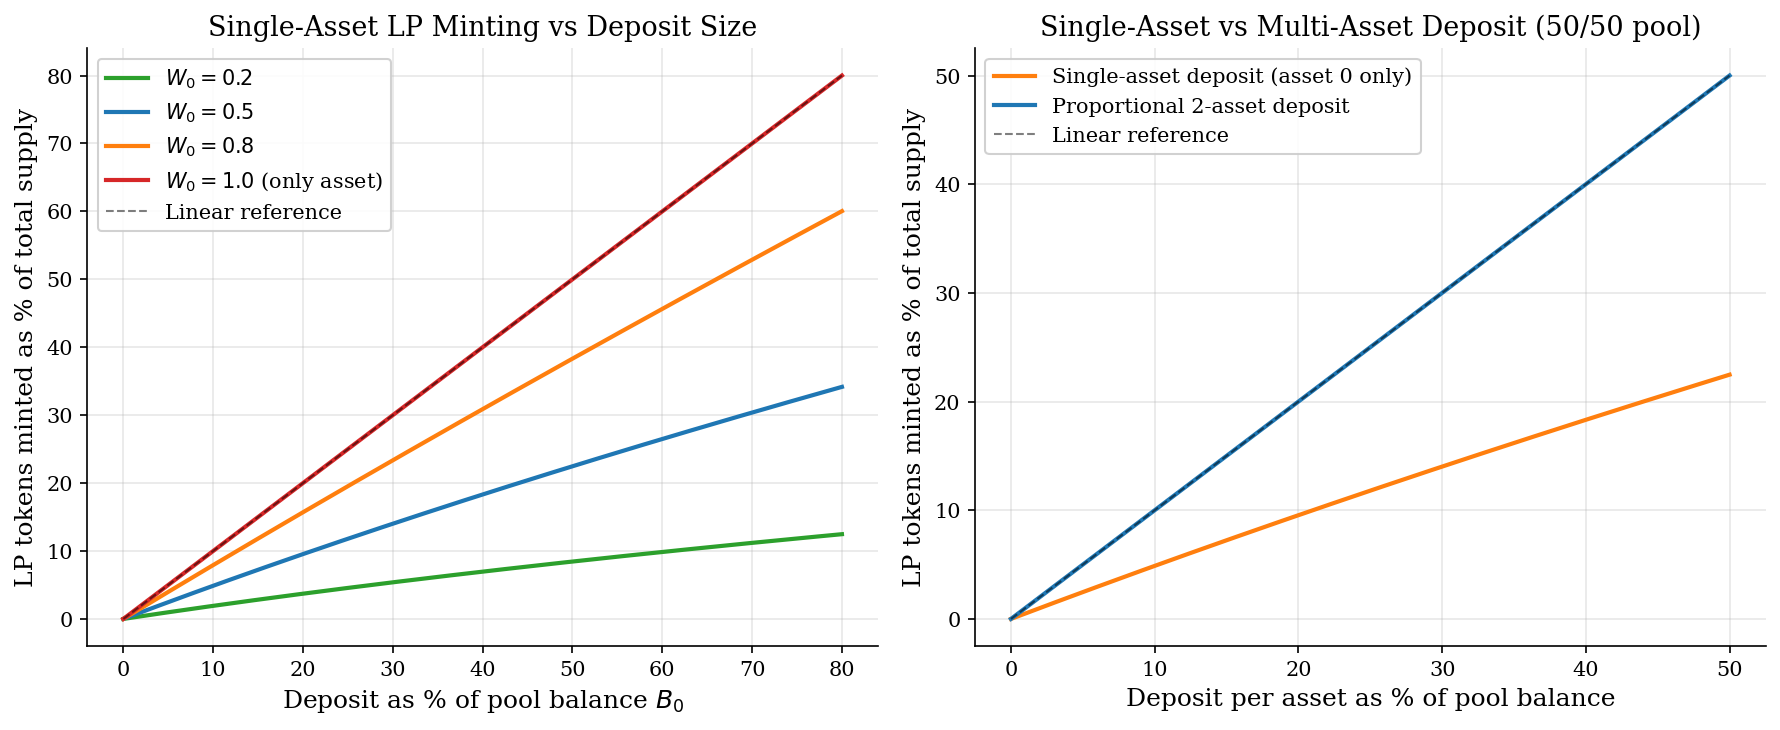

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib import rcParams

# --- Style settings for academic thesis ---
rcParams['font.family'] = 'serif'
rcParams['font.size'] = 11
rcParams['axes.labelsize'] = 12
rcParams['axes.titlesize'] = 13
rcParams['legend.fontsize'] = 10
rcParams['xtick.labelsize'] = 10
rcParams['ytick.labelsize'] = 10
rcParams['figure.dpi'] = 150
rcParams['axes.grid'] = True
rcParams['grid.alpha'] = 0.3
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False


# ── Helpers ──────────────────────────────────────────────────────────────────

def invariant(x, wx, wy, V):
    """y such that x^wx * y^wy = V"""
    return (V / (x ** wx)) ** (1 / wy)

def calc_out(balance_in, weight_in, balance_out, weight_out, amount_in, fee=0.0):
    """Swap output formula: balanceOut * (1 - (balanceIn / (balanceIn + amountIn*(1-fee)))^(wIn/wOut))"""
    effective_in = amount_in * (1 - fee)
    ratio = balance_in / (balance_in + effective_in)
    return balance_out * (1 - ratio ** (weight_in / weight_out))

def spot_price(bx, wx, by, wy):
    return (bx / wx) / (by / wy)

def price_impact(balance_in, weight_in, balance_out, weight_out, amount_in):
    p_spot = spot_price(balance_in, weight_in, balance_out, weight_out)
    delta_out = calc_out(balance_in, weight_in, balance_out, weight_out, amount_in)
    p_eff = amount_in / delta_out
    return (p_eff - p_spot) / p_spot * 100  # percentage

def lp_minted(total_lp, balance, delta):
    """Single-asset LP minting: totalLP * ((1 + delta/balance)^W - 1), W=0.5 for simplicity"""
    W = 0.5
    return total_lp * ((1 + delta / balance) ** W - 1)


# ── Figure 1: Invariant Curves ────────────────────────────────────────────────

fig1, ax1 = plt.subplots(figsize=(6.5, 5))

x = np.linspace(100, 2000, 500)
B0 = 1000  # initial balances
configs = [
    (0.5, 0.5, '#1f77b4', r'$W_x = W_y = 0.5$ (Uniswap)'),
    (0.8, 0.2, '#ff7f0e', r'$W_x = 0.8,\ W_y = 0.2$'),
    (0.2, 0.8, '#2ca02c', r'$W_x = 0.2,\ W_y = 0.8$'),
    (0.95, 0.05, '#d62728', r'$W_x = 0.95,\ W_y = 0.05$'),
]

for wx, wy, color, label in configs:
    V = B0 ** wx * B0 ** wy
    y = invariant(x, wx, wy, V)
    mask = (y > 50) & (y < 5000)
    ax1.plot(x[mask], y[mask], color=color, linewidth=2, label=label)

ax1.scatter([B0], [B0], color='black', zorder=5, s=60, label='Initial state $(B_x=B_y=1000)$')
ax1.set_xlabel(r'$B_x$ (balance of token $x$)')
ax1.set_ylabel(r'$B_y$ (balance of token $y$)')
ax1.set_title('Invariant Curves for Different Weight Configurations')
ax1.legend(loc='upper right', framealpha=0.9)
ax1.set_xlim(100, 2000)
ax1.set_ylim(0, 3000)
fig1.tight_layout()
fig1.savefig('fig1_invariant_curves.pdf', bbox_inches='tight')
fig1.savefig('fig1_invariant_curves.png', bbox_inches='tight')
print("Fig 1 saved.")


# ── Figure 2: Price Impact vs Trade Size ─────────────────────────────────────

fig2, ax2 = plt.subplots(figsize=(6.5, 5))

B = 1000  # pool balance
trade_sizes = np.linspace(1, 600, 300)  # % of pool balance

configs_pi = [
    (0.5, 0.5, '#1f77b4', r'$W_x = W_y = 0.5$'),
    (0.8, 0.2, '#ff7f0e', r'$W_x = 0.8,\ W_y = 0.2$'),
    (0.2, 0.8, '#2ca02c', r'$W_x = 0.2,\ W_y = 0.8$'),
]

for wx, wy, color, label in configs_pi:
    impacts = [price_impact(B, wx, B, wy, dx) for dx in trade_sizes]
    ax2.plot(trade_sizes / B * 100, impacts, color=color, linewidth=2, label=label)

ax2.axvline(x=10, color='gray', linestyle='--', linewidth=1, alpha=0.7, label='10% of pool')
ax2.set_xlabel(r'Trade size as % of pool balance $B_x$')
ax2.set_ylabel('Price Impact (%)')
ax2.set_title('Price Impact vs Trade Size')
ax2.legend(framealpha=0.9)
fig2.tight_layout()
fig2.savefig('fig2_price_impact.pdf', bbox_inches='tight')
fig2.savefig('fig2_price_impact.png', bbox_inches='tight')
print("Fig 2 saved.")


# ── Figure 3: Weight Influence on Price Impact ───────────────────────────────

fig3, axes3 = plt.subplots(1, 2, figsize=(12, 5))

# Left: fixed trade size, vary weight ratio
weight_ratios = np.linspace(0.1, 10, 200)  # Wx/Wy
trade_fixed = 100  # 10% of pool
B = 1000

impacts_ratio = []
for r in weight_ratios:
    wx = r / (1 + r)
    wy = 1 / (1 + r)
    impacts_ratio.append(price_impact(B, wx, B, wy, trade_fixed))

axes3[0].plot(weight_ratios, impacts_ratio, color='#1f77b4', linewidth=2)
axes3[0].axvline(x=1, color='gray', linestyle='--', linewidth=1, alpha=0.7, label=r'$W_x/W_y = 1$ (equal weights)')
axes3[0].set_xlabel(r'Weight ratio $W_x / W_y$')
axes3[0].set_ylabel('Price Impact (%)')
axes3[0].set_title(r'Price Impact vs Weight Ratio ($\Delta x = 10\%$ of pool)')
axes3[0].legend()

# Right: heatmap — trade size x weight ratio
trade_sizes_2 = np.linspace(10, 500, 50)
weight_ratios_2 = np.linspace(0.1, 5, 50)
Z = np.zeros((len(weight_ratios_2), len(trade_sizes_2)))

for i, r in enumerate(weight_ratios_2):
    for j, dx in enumerate(trade_sizes_2):
        wx = r / (1 + r)
        wy = 1 / (1 + r)
        Z[i, j] = price_impact(B, wx, B, wy, dx)

im = axes3[1].contourf(trade_sizes_2 / B * 100, weight_ratios_2, Z, levels=20, cmap='YlOrRd')
plt.colorbar(im, ax=axes3[1], label='Price Impact (%)')
axes3[1].set_xlabel(r'Trade size as % of pool')
axes3[1].set_ylabel(r'Weight ratio $W_x / W_y$')
axes3[1].set_title('Price Impact Heatmap')

fig3.tight_layout()
fig3.savefig('fig3_weight_influence.pdf', bbox_inches='tight')
fig3.savefig('fig3_weight_influence.png', bbox_inches='tight')
print("Fig 3 saved.")


# ── Figure 4: LP Token Minting vs Deposit Amount ─────────────────────────────

fig4, axes4 = plt.subplots(1, 2, figsize=(12, 5))

total_lp = 1_000_000
B = 1_000_000
deposits = np.linspace(0, B * 0.8, 300)

# Left: single-asset, vary weights
weights_lp = [
    (0.2, '#2ca02c', r'$W_0 = 0.2$'),
    (0.5, '#1f77b4', r'$W_0 = 0.5$'),
    (0.8, '#ff7f0e', r'$W_0 = 0.8$'),
    (1.0, '#d62728', r'$W_0 = 1.0$ (only asset)'),
]

for W, color, label in weights_lp:
    lp_amounts = np.array([total_lp * ((1 + d / B) ** W - 1) for d in deposits])
    axes4[0].plot(deposits / B * 100, lp_amounts / total_lp * 100, color=color, linewidth=2, label=label)

# Reference: linear
axes4[0].plot(deposits / B * 100, deposits / B * 100, 'k--', linewidth=1, alpha=0.5, label='Linear reference')
axes4[0].set_xlabel(r'Deposit as % of pool balance $B_0$')
axes4[0].set_ylabel(r'LP tokens minted as % of total supply')
axes4[0].set_title('Single-Asset LP Minting vs Deposit Size')
axes4[0].legend(framealpha=0.9)

# Right: multi-asset, show how balanced deposit is more efficient
# Compare single-asset vs proportional 2-asset deposit
deposits2 = np.linspace(0, B * 0.5, 300)
W0, W1 = 0.5, 0.5

lp_single = [total_lp * ((1 + d / B) ** W0 - 1) for d in deposits2]
# Proportional: deposit d in asset 0 and d in asset 1
lp_multi = [total_lp * (((1 + d / B) ** W0) * ((1 + d / B) ** W1) - 1) for d in deposits2]

axes4[1].plot(deposits2 / B * 100, [x / total_lp * 100 for x in lp_single],
              color='#ff7f0e', linewidth=2, label='Single-asset deposit (asset 0 only)')
axes4[1].plot(deposits2 / B * 100, [x / total_lp * 100 for x in lp_multi],
              color='#1f77b4', linewidth=2, label='Proportional 2-asset deposit')
axes4[1].plot(deposits2 / B * 100, deposits2 / B * 100, 'k--', linewidth=1, alpha=0.5, label='Linear reference')
axes4[1].set_xlabel(r'Deposit per asset as % of pool balance')
axes4[1].set_ylabel(r'LP tokens minted as % of total supply')
axes4[1].set_title('Single-Asset vs Multi-Asset Deposit (50/50 pool)')
axes4[1].legend(framealpha=0.9)

fig4.tight_layout()
fig4.savefig('fig4_lp_minting.pdf', bbox_inches='tight')
fig4.savefig('fig4_lp_minting.png', bbox_inches='tight')
print("Fig 4 saved.")

print("\nAll figures saved to /")
print("PDF versions ready for LaTeX inclusion.")

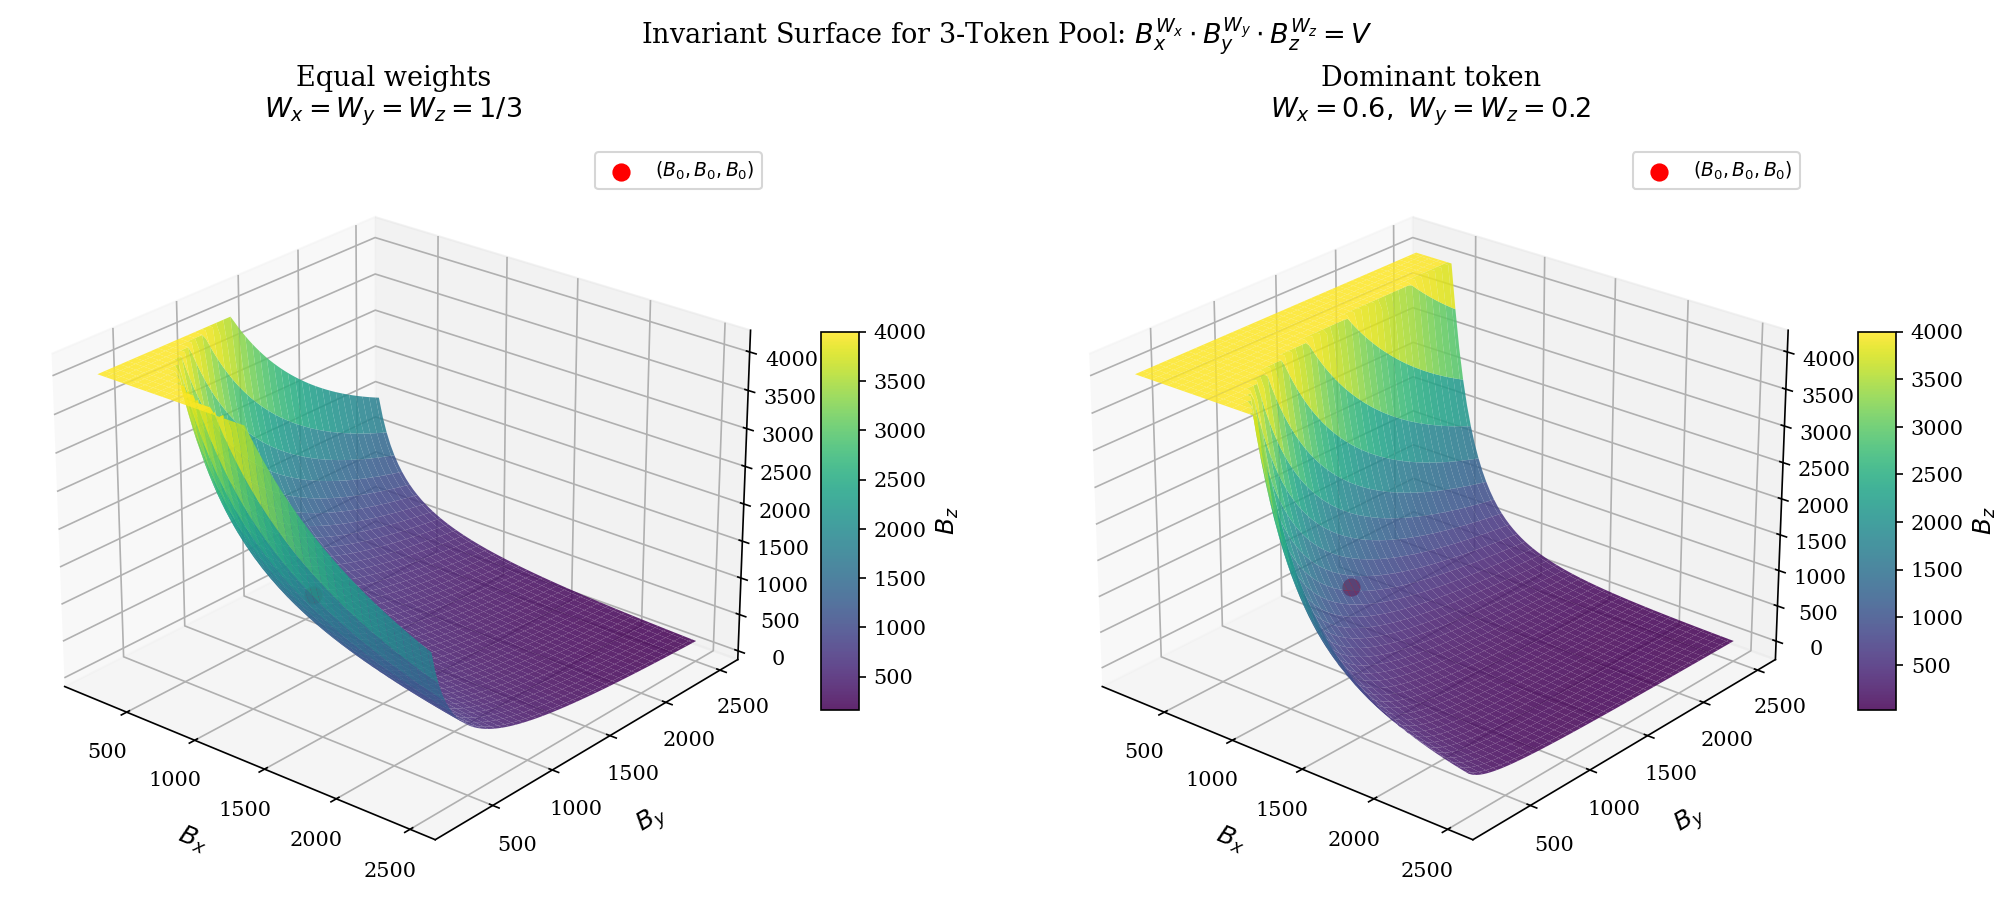

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
from mpl_toolkits.mplot3d import Axes3D

rcParams['font.family'] = 'serif'
rcParams['font.size'] = 11
rcParams['figure.dpi'] = 150

# Pool with 3 tokens: x^Wx * y^Wy * z^Wz = V
# We fix z and plot the surface x, y -> z such that invariant holds
# i.e. z = (V / (x^Wx * y^Wy))^(1/Wz)

configs = [
    (1/3, 1/3, 1/3, 'Equal weights\n$W_x=W_y=W_z=1/3$'),
    (0.6, 0.2, 0.2, 'Dominant token\n$W_x=0.6,\\ W_y=W_z=0.2$'),
]

fig = plt.figure(figsize=(14, 6))

for idx, (wx, wy, wz, title) in enumerate(configs):
    B0 = 1000
    V = B0**wx * B0**wy * B0**wz

    x = np.linspace(200, 2500, 80)
    y = np.linspace(200, 2500, 80)
    X, Y = np.meshgrid(x, y)

    # z such that invariant holds
    Z = (V / (X**wx * Y**wy)) ** (1/wz)

    # clip for visualization
    Z = np.clip(Z, 0, 4000)

    ax = fig.add_subplot(1, 2, idx+1, projection='3d')

    surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.85,
                           linewidth=0, antialiased=True)

    # Mark initial state point
    ax.scatter([B0], [B0], [B0], color='red', s=60, zorder=5, label='$(B_0, B_0, B_0)$')

    ax.set_xlabel(r'$B_x$', labelpad=8)
    ax.set_ylabel(r'$B_y$', labelpad=8)
    ax.set_zlabel(r'$B_z$', labelpad=8)
    ax.set_title(title, pad=12)
    ax.view_init(elev=25, azim=-50)

    fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label=r'$B_z$')
    ax.legend(loc='upper right', fontsize=9)

fig.suptitle(
    r'Invariant Surface for 3-Token Pool: $B_x^{W_x} \cdot B_y^{W_y} \cdot B_z^{W_z} = V$',
    fontsize=13, y=1.01
)

fig.tight_layout()
fig.savefig('fig5_invariant_surface.pdf', bbox_inches='tight')
fig.savefig('fig5_invariant_surface.png', bbox_inches='tight')

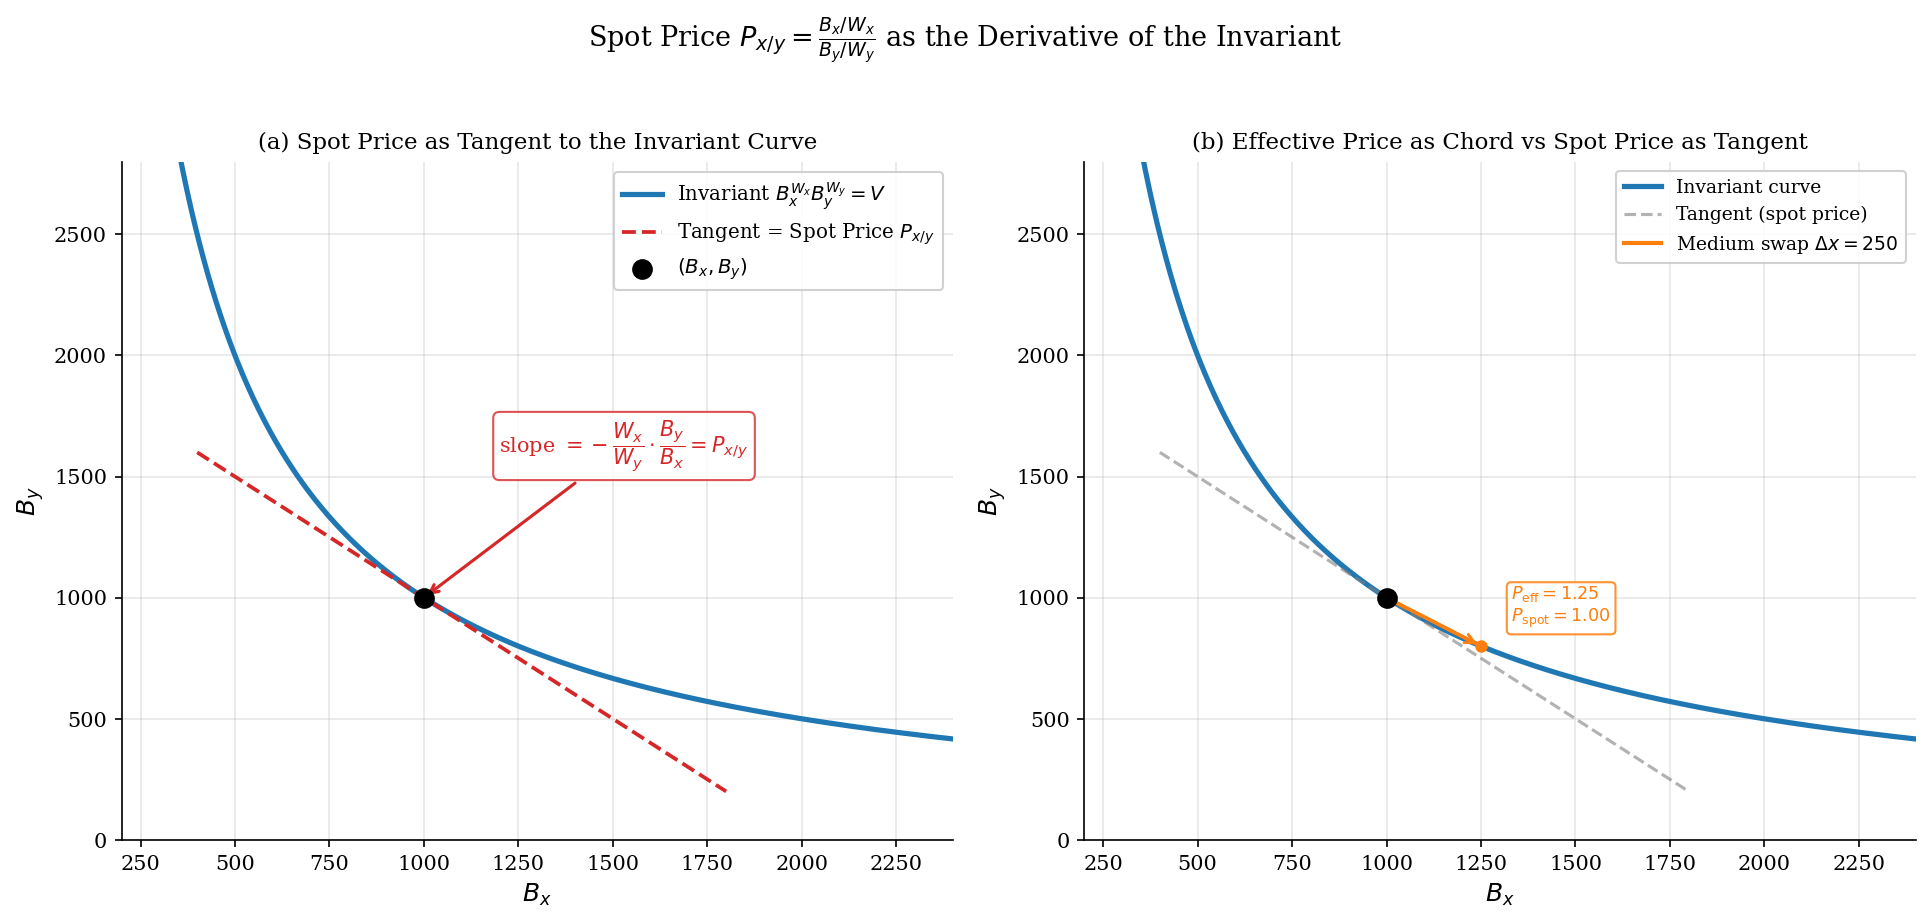

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.size'] = 11
rcParams['figure.dpi'] = 150
rcParams['axes.spines.top'] = False
rcParams['axes.spines.right'] = False

fig, axes = plt.subplots(1, 2, figsize=(13, 6))

# ── Parameters ────────────────────────────────────────────────────────────────
Bx, By = 1000.0, 1000.0
Wx, Wy = 0.5, 0.5
V = Bx**Wx * By**Wy

x = np.linspace(200, 2400, 600)
y = (V / x**Wx) ** (1/Wy)

def spot_price_slope(x0, y0):
    return -(Wx/Wy) * (y0/x0)

# Tangent line at (Bx, By)
slope_tangent = spot_price_slope(Bx, By)
x_tang = np.linspace(400, 1800, 100)
y_tang = By + slope_tangent * (x_tang - Bx)

# ── LEFT PLOT: spot price as tangent ─────────────────────────────────────────
ax = axes[0]

ax.plot(x, y, color='#1f77b4', linewidth=2.5, label=r'Invariant $B_x^{W_x} B_y^{W_y} = V$')

mask_tang = (y_tang > 0) & (y_tang < 3000) & (x_tang > 0)
ax.plot(x_tang[mask_tang], y_tang[mask_tang], color='#d62728', linewidth=1.8,
        linestyle='--', label=r'Tangent = Spot Price $P_{x/y}$')

ax.scatter([Bx], [By], color='black', zorder=6, s=80, label=r'$(B_x, B_y)$')

ax.annotate(
    r'slope $= -\dfrac{W_x}{W_y}\cdot\dfrac{B_y}{B_x} = P_{x/y}$',
    xy=(Bx, By), xytext=(1200, 1600),
    arrowprops=dict(arrowstyle='->', color='#d62728', lw=1.5),
    fontsize=10, color='#d62728',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#d62728', alpha=0.8)
)

ax.set_xlabel(r'$B_x$')
ax.set_ylabel(r'$B_y$')
ax.set_title('(a) Spot Price as Tangent to the Invariant Curve', fontsize=11)
ax.legend(loc='upper right', framealpha=0.9, fontsize=9.5)
ax.set_xlim(200, 2400)
ax.set_ylim(0, 2800)
ax.grid(alpha=0.3)

# ── RIGHT PLOT: spot price vs effective price (chord) ────────────────────────
ax2 = axes[1]

swap_configs = [
    (250, '#ff7f0e', r'Medium swap $\Delta x = 250$'),
]

ax2.plot(x, y, color='#1f77b4', linewidth=2.5, label=r'Invariant curve')
ax2.scatter([Bx], [By], color='black', zorder=6, s=80)

ax2.plot(x_tang[mask_tang], y_tang[mask_tang], color='gray', linewidth=1.5,
         linestyle='--', alpha=0.6, label=r'Tangent (spot price)')

for dx, color, label in swap_configs:
    x1 = Bx + dx
    y1 = (V / x1**Wx) ** (1/Wy)
    dy = y1 - By

    ax2.plot([Bx, x1], [By, y1], color=color, linewidth=1.8,
             linestyle='-', marker='o', markersize=5)

    p_eff = dx / abs(dy)
    p_spot = (Bx/Wx) / (By/Wy)

    ax2.annotate(
        f'$P_{{\\rm eff}}={p_eff:.2f}$\n$P_{{\\rm spot}}={p_spot:.2f}$',
        xy=(x1, y1), xytext=(x1 + 80, y1 + 100),
        fontsize=8.5, color=color,
        bbox=dict(boxstyle='round,pad=0.25', facecolor='white', edgecolor=color, alpha=0.85)
    )

    ax2.annotate('', xy=(x1, y1), xytext=(Bx, By),
                 arrowprops=dict(arrowstyle='->', color=color, lw=1.4))

    ax2.plot([], [], color=color, linewidth=2, label=label)

ax2.set_xlabel(r'$B_x$')
ax2.set_ylabel(r'$B_y$')
ax2.set_title('(b) Effective Price as Chord vs Spot Price as Tangent', fontsize=11)
ax2.legend(loc='upper right', framealpha=0.9, fontsize=9)
ax2.set_xlim(200, 2400)
ax2.set_ylim(0, 2800)
ax2.grid(alpha=0.3)

fig.suptitle(
    r'Spot Price $P_{x/y} = \frac{B_x/W_x}{B_y/W_y}$ as the Derivative of the Invariant',
    fontsize=13, y=1.02
)

fig.tight_layout()
plt.savefig('fig_spot_price_derivative.pdf', bbox_inches='tight')
plt.savefig('fig_spot_price_derivative.png', bbox_inches='tight')
plt.show()